In [65]:
## Installing the required libraries for downloading the datasets
!pip install opendatasets legacy-cgi --quiet

In [66]:
## getting the data
import opendatasets as od; od.download("https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign",)

Skipping, found downloaded files in "./gtsrb-german-traffic-sign" (use force=True to force download)


In [67]:
## required libraries to list directories
import os
os.listdir("gtsrb-german-traffic-sign")

['train',
 'Test',
 'Meta.csv',
 'Test.csv',
 'Train',
 'Train.csv',
 'Meta',
 'test',
 'meta']

In [68]:
## Importing libraries for loading data and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Visulizing the classess and their count

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="dark", rc=custom_params,color_codes=True)
sns.set_palette("rocket")

In [69]:
## reading the CSV files
meta_csv=pd.read_csv("gtsrb-german-traffic-sign/Meta.csv")
test_csv=pd.read_csv("gtsrb-german-traffic-sign/Test.csv")
train_csv=pd.read_csv("gtsrb-german-traffic-sign/Train.csv")

print("Checking data for Meta.csv.")
display(meta_csv.head())
print("-"*30,'\n')
print("Checking data for Test.csv.")
display(test_csv.head())
print("-"*30,'\n')
print("Checking data for Train.csv.")
display(train_csv.head())

Checking data for Meta.csv.


,Path,ClassId,ShapeId,ColorId,SignId
0,Meta/27.png,27,0,0,1.32
1,Meta/0.png,0,1,0,3.29
2,Meta/1.png,1,1,0,3.29
3,Meta/10.png,10,1,0,3.27
4,Meta/11.png,11,0,0,1.22


------------------------------ 

Checking data for Test.csv.


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


------------------------------ 

Checking data for Train.csv.


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [70]:
data_dir="/home/prashant/Downloads/gtsrb-german-traffic-sign/"
train_dir=data_dir+"Train/"
test_dir=data_dir+"Test/"

[train_dir,test_dir]

['/home/prashant/Downloads/gtsrb-german-traffic-sign/Train/',
 '/home/prashant/Downloads/gtsrb-german-traffic-sign/Test/']

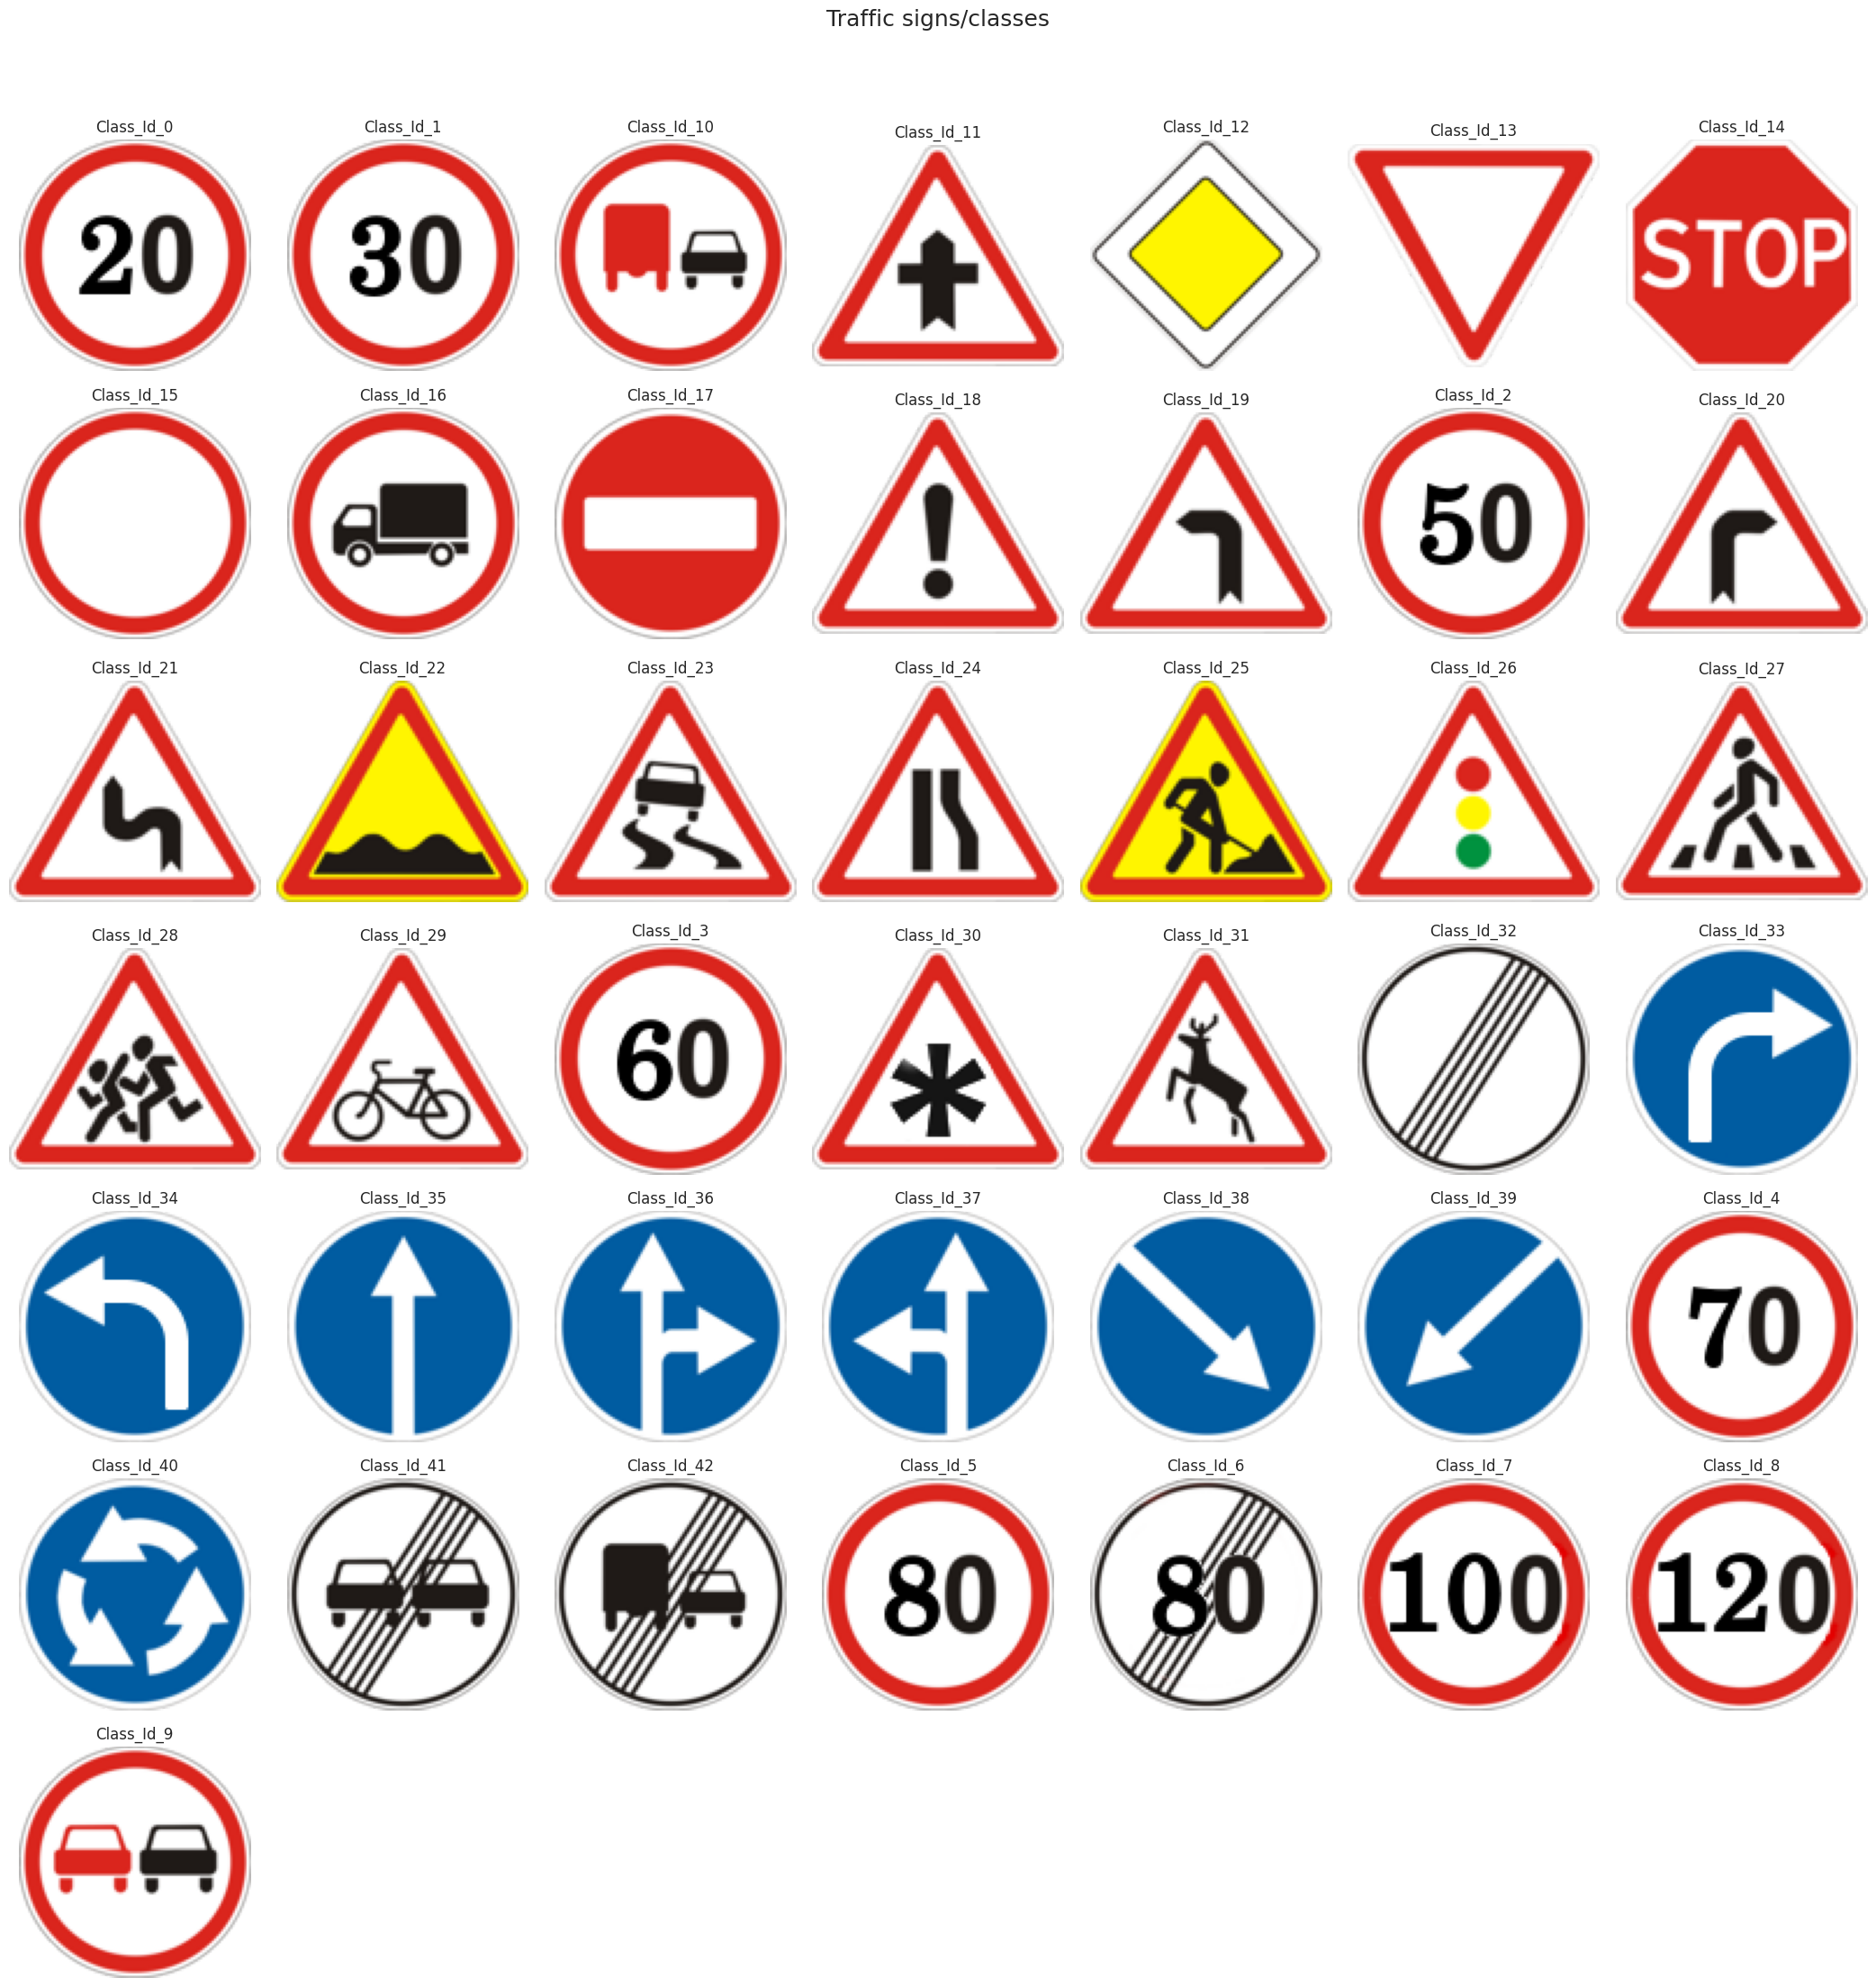

In [71]:
from PIL import Image
import glob

img_path=sorted(glob.glob(data_dir+"Meta/*.png"))

## Creating the subplot grid
rows, cols=7,7
fig, axes=plt.subplots(nrows=rows,ncols=cols, figsize=(21,21))
axes=axes.flatten()

## Turn off axes for all the subplots
for ax in axes:
  ax.axis("off")

## ploting the images
for i, path in enumerate(img_path):
  img=Image.open(path)
  axes[i].imshow(img)
  axes[i].set_title(f"Class_Id_{path.split("/")[-1].split(".")[0]}")

plt.tight_layout()
plt.suptitle("Traffic signs/classes",fontsize=18, y=1.05)
plt.show()

In [72]:
## Preparing train_df & test_df with images path and class name
def generate_paths_labels(directory):

  """
  Args: directory
  directory --> Provide the path of the directory where the images are present.
  """
  imgs_path=[]
  imgs_labels=[]
  for class_id in range(43):
    class_folder=os.path.join(str(directory)+str(class_id))

    if not os.path.exists(class_folder):
      continue

    for files in os.listdir(class_folder):
      if files.lower().endswith((".png",".jpg",".jpeg",".ppm")):
        img_full_path=os.path.join(class_folder,files)
        if os.path.isfile(img_full_path):
          imgs_path.append(img_full_path)
          imgs_labels.append(int(class_id))

  df=pd.DataFrame({'paths':imgs_path,'encoded_labels':imgs_labels})

  return df

train_df=generate_paths_labels(train_dir)
display(train_df)

,paths,encoded_labels
0,/home/prashant/Downloads/gtsrb-german-traffic-...,0
1,/home/prashant/Downloads/gtsrb-german-traffic-...,0
2,/home/prashant/Downloads/gtsrb-german-traffic-...,0
3,/home/prashant/Downloads/gtsrb-german-traffic-...,0
4,/home/prashant/Downloads/gtsrb-german-traffic-...,0
...,...,...
39204,/home/prashant/Downloads/gtsrb-german-traffic-...,42
39205,/home/prashant/Downloads/gtsrb-german-traffic-...,42
39206,/home/prashant/Downloads/gtsrb-german-traffic-...,42
39207,/home/prashant/Downloads/gtsrb-german-traffic-...,42


In [73]:
## For test images
test_imgs_paths=[]

for files in os.listdir(test_dir):
      if files.lower().endswith((".png",".jpg",".jpeg",".ppm")):
        img_full_path=os.path.join(test_dir,files)
        if os.path.isfile(img_full_path):
          test_imgs_paths.append(img_full_path)

test_df=pd.DataFrame({'paths':test_imgs_paths})
display(test_df)

,paths
0,/home/prashant/Downloads/gtsrb-german-traffic-...
1,/home/prashant/Downloads/gtsrb-german-traffic-...
2,/home/prashant/Downloads/gtsrb-german-traffic-...
3,/home/prashant/Downloads/gtsrb-german-traffic-...
4,/home/prashant/Downloads/gtsrb-german-traffic-...
...,...
12625,/home/prashant/Downloads/gtsrb-german-traffic-...
12626,/home/prashant/Downloads/gtsrb-german-traffic-...
12627,/home/prashant/Downloads/gtsrb-german-traffic-...
12628,/home/prashant/Downloads/gtsrb-german-traffic-...


In [74]:
## Mapping the labels in train_df

labels = {
    0: 'Speed limit (20km/h)',
    1: 'Speed limit (30km/h)',
    2: 'Speed limit (50km/h)',
    3: 'Speed limit (60km/h)',
    4: 'Speed limit (70km/h)',
    5: 'Speed limit (80km/h)',
    6: 'End of speed limit (80km/h)',
    7: 'Speed limit (100km/h)',
    8: 'Speed limit (120km/h)',
    9: 'No passing',
    10: 'No passing veh over 3.5 tons',
    11: 'Right-of-way at the next intersection',
    12: 'Priority road',
    13: 'Yield',
    14: 'Stop',
    15: 'No vehicles',
    16: 'Veh > 3.5 tons prohibited',
    17: 'No entry',
    18: 'General caution',
    19: 'Dangerous curve left',
    20: 'Dangerous curve right',
    21: 'Double curve',
    22: 'Bumpy road',
    23: 'Slippery road',
    24: 'Road narrows on the right',
    25: 'Road work',
    26: 'Traffic signals',
    27: 'Pedestrians',
    28: 'Children crossing',
    29: 'Bicycles crossing',
    30: 'Beware of ice/snow',
    31: 'Wild animals crossing',
    32: 'End speed + passing limits',
    33: 'Turn right ahead',
    34: 'Turn left ahead',
    35: 'Ahead only',
    36: 'Go straight or right',
    37: 'Go straight or left',
    38: 'Keep right',
    39: 'Keep left',
    40: 'Roundabout mandatory',
    41: 'End of no passing',
    42: 'End no passing veh > 3.5 tons'
}

train_df['labels'] = train_df['encoded_labels'].map(labels)
display(train_df.sample(10))

,paths,encoded_labels,labels
6682,/home/prashant/Downloads/gtsrb-german-traffic-...,4,Speed limit (70km/h)
2476,/home/prashant/Downloads/gtsrb-german-traffic-...,2,Speed limit (50km/h)
4976,/home/prashant/Downloads/gtsrb-german-traffic-...,3,Speed limit (60km/h)
15387,/home/prashant/Downloads/gtsrb-german-traffic-...,10,No passing veh over 3.5 tons
8959,/home/prashant/Downloads/gtsrb-german-traffic-...,5,Speed limit (80km/h)
28950,/home/prashant/Downloads/gtsrb-german-traffic-...,25,Road work
15968,/home/prashant/Downloads/gtsrb-german-traffic-...,10,No passing veh over 3.5 tons
34850,/home/prashant/Downloads/gtsrb-german-traffic-...,35,Ahead only
15549,/home/prashant/Downloads/gtsrb-german-traffic-...,10,No passing veh over 3.5 tons
6645,/home/prashant/Downloads/gtsrb-german-traffic-...,4,Speed limit (70km/h)


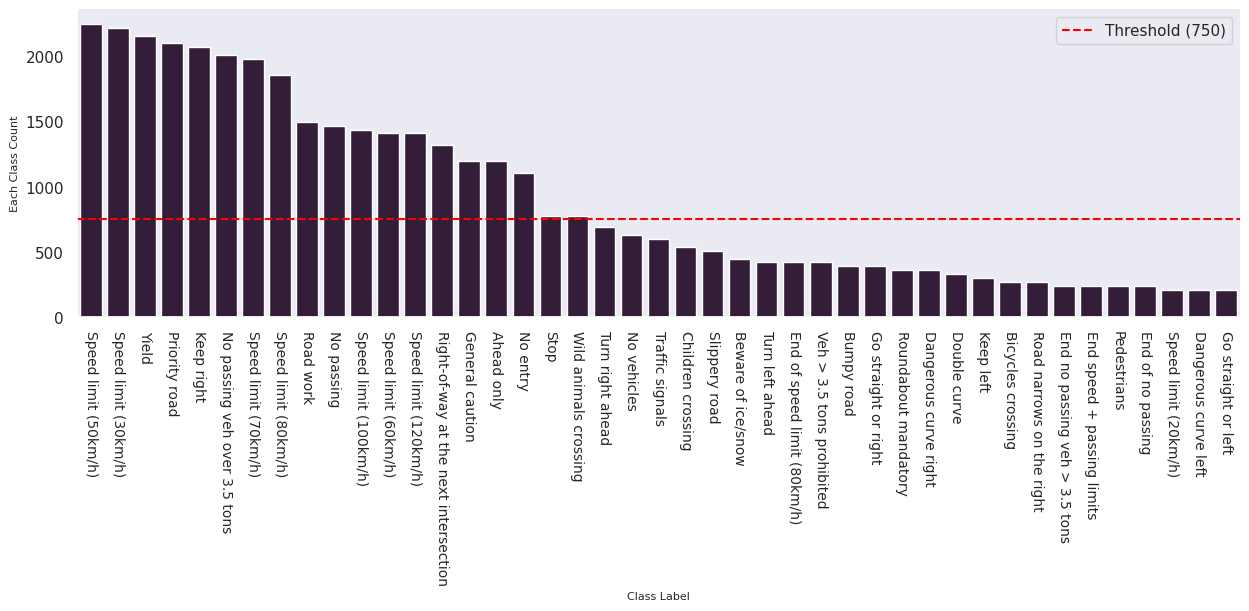

In [75]:
## getting the class count data
class_data = train_df['labels'].value_counts().reset_index()

## defining figure size
_,fig=plt.subplots(figsize=(15,4))

## Countplot
threshold_value=750
axes=sns.countplot(x='labels', data=train_df, order=class_data['labels'])
axes.axhline(y=threshold_value, color='red', linestyle='--',label=f'Threshold ({threshold_value})')
plt.xticks(rotation=-90,fontsize=10)
axes.legend()
plt.xlabel("Class Label",fontsize=8)
plt.ylabel("Each Class Count",fontsize=8)
plt.show()


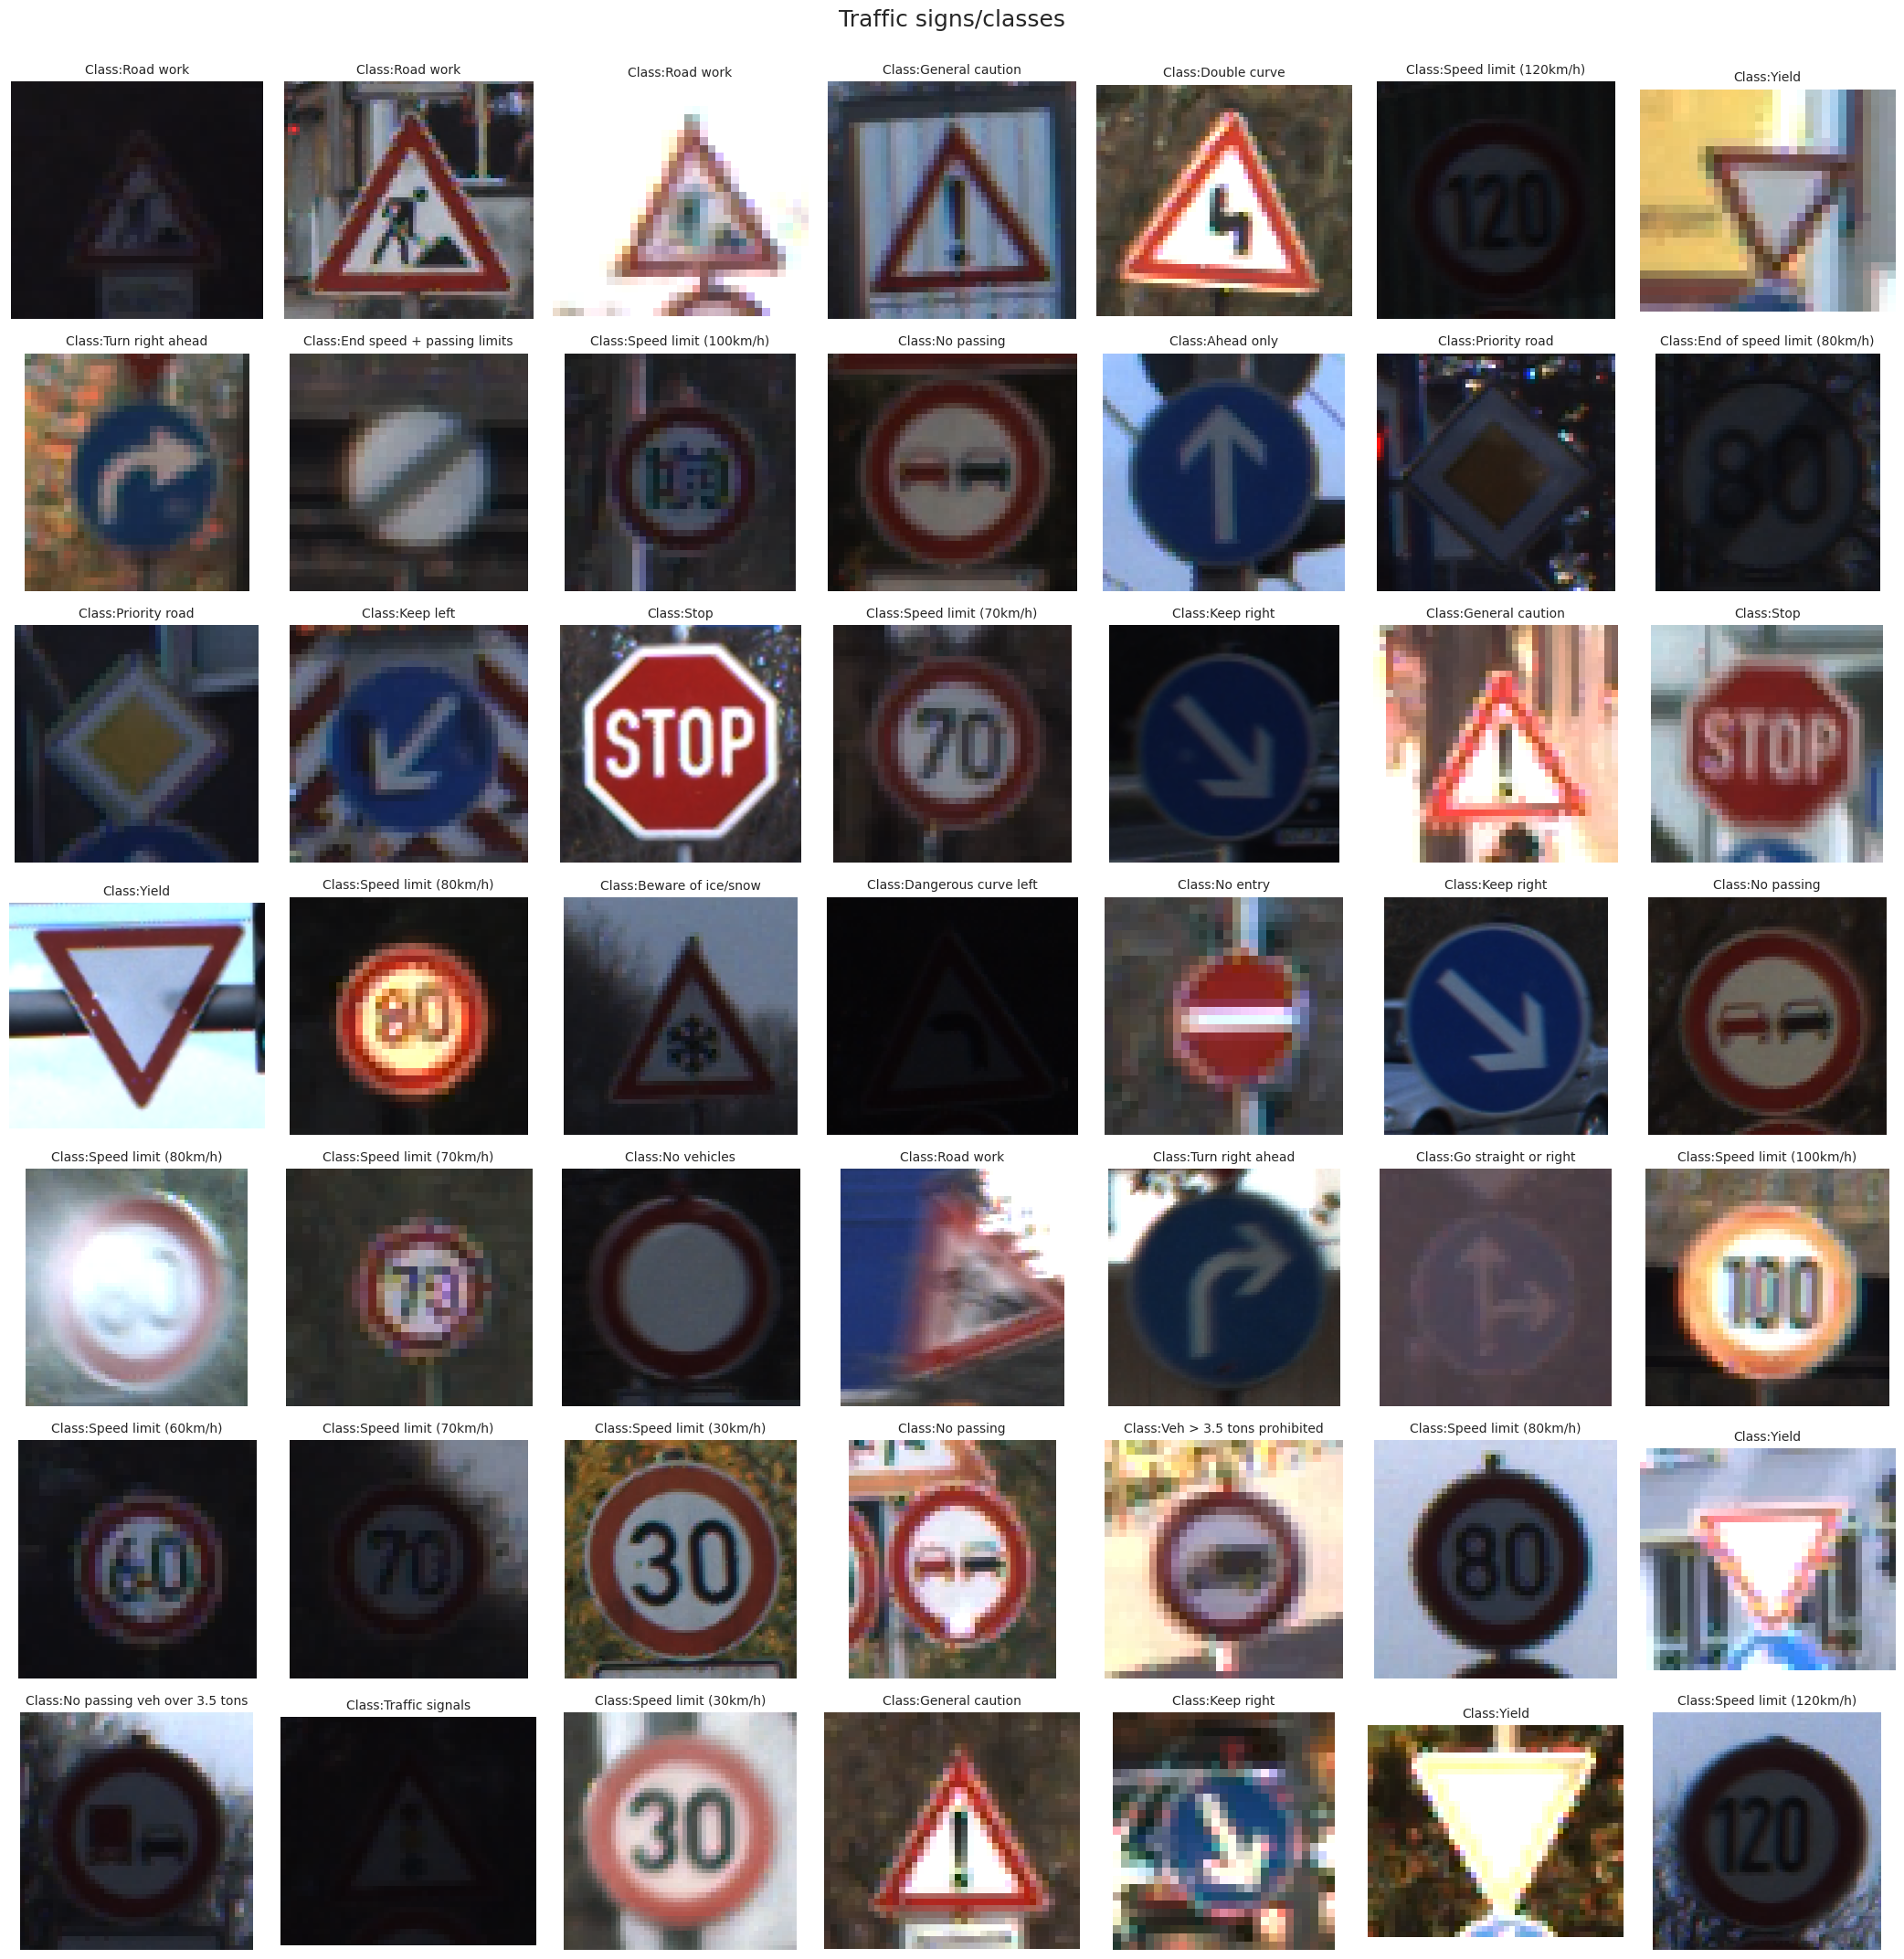

In [76]:
sample_df=train_df.sample(49)
paths=sample_df["paths"].values
labels=sample_df["labels"].values

## Creating the subplot grid
rows, cols=7,7
fig, axes=plt.subplots(nrows=rows,ncols=cols, figsize=(21,21))
axes=axes.flatten()

## Turn off axes for all the subplots
for ax in axes:
  ax.axis("off")

## ploting the images
for i, (path, label) in enumerate(zip(paths,labels)):
  img=Image.open(path)
  axes[i].imshow(img)
  axes[i].set_title(f"Class:{label}",fontsize=10)

plt.tight_layout()
plt.suptitle("Traffic signs/classes",fontsize=18, y=1.02)
plt.show()

In [77]:
!pip install opencv-python --quiet

In [78]:
import cv2

def load_images(df,img_size=(32,32)):
  images = []
  labels = []
  has_labels = 'encoded_labels' in df.columns # Check if 'encoded_labels' column exists

  for idx, row in df.iterrows():
    img = cv2.imread(row['paths'])
    img = cv2.resize(img,img_size)
    img = img.astype("float32") / 255.0
    if img is not None:
      images.append(img)
      if has_labels: # Only append label if the column exists
        labels.append(row['encoded_labels'])
    if (idx+1)%5000 == 0:
      print(f"{idx+1} images loaded")
  return np.array(images), np.array(labels) if has_labels else np.array([])

In [79]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 0=all, 1=info, 2=warning, 3=error
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

print("TensorFlow Version:",tf.__version__)
print(tf.config.list_physical_devices())

TensorFlow Version: 2.20.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [80]:
## normalizing and getting images data
print("Executing Training sets:",'\n')
x_train, y_train = load_images(train_df)
y_train = to_categorical(y_train, num_classes=43)
print(f"Train Set Shape:{x_train.shape}")
print(f"Train Label Shape:{len(y_train)}")

## normalizing and getting images data
print("*"*35,'\n')
print("Executing Test sets:",'\n')
x_test, _ = load_images(test_df)
print(f"Test Set Shape:{x_test.shape}")

Executing Training sets: 

5000 images loaded
10000 images loaded
15000 images loaded
20000 images loaded
25000 images loaded
30000 images loaded
35000 images loaded
Train Set Shape:(39209, 32, 32, 3)
Train Label Shape:39209
*********************************** 

Executing Test sets: 

5000 images loaded
10000 images loaded
Test Set Shape:(12630, 32, 32, 3)


In [81]:
## Spliting the Trainning set to Train & Validation

from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42,stratify=y_train)

print(f"Shape of the Train sets/Validation sets:{X_train.shape,Y_train.shape}/{X_val.shape,Y_val.shape}")

Shape of the Train sets/Validation sets:((31367, 32, 32, 3), (31367, 43))/((7842, 32, 32, 3), (7842, 43))


## Initializing CNN for model trainning

In [ ]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras import layers
from tensorflow.keras.layers import (
    Dense,
    Conv2D,
    Flatten,
    Input,
    MaxPooling2D,
    Dropout,
    BatchNormalization,
    Reshape
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D

In [83]:
num_classes=train_df['encoded_labels'].nunique()

model = Sequential([
    Input(shape=(32, 32, 3)),

    ## First Block
    Conv2D(32,(3,3),activation='relu',padding='same',kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    ## Second Block
    Conv2D(64,(3,3),activation='relu',padding='same',kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    ## Third Block
    Conv2D(128,(3,3),activation='relu',padding='same',kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.35),

    ## Global Average Pooling Layer
    GlobalAveragePooling2D(),

    ## First Dense Layer
    Dense(256,activation='relu',kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.5),

    ## Second Dense Layer
    Dense(num_classes, activation='softmax')
])

In [84]:
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

In [85]:
print("Model Summary:\n")
model.summary()

Model Summary:



Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_13     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 139,243 (543.92 KB)

 Trainable params: 138,283 (540.17 KB)

 Non-trainable params: 960 (3.75 KB)

### **Breaking down the model**

**Input**: Starting with `32x32x32` after the first `Conv2D`. So original input is probably `32x32x3` RGB images.

**Architecture pattern**: Repeating `Conv2D -> BatchNorm -> MaxPool -> Dropout` 3 times, doubling filters each block: 32 -> 64 -> 128. This is a solid VGG-style pattern.

**Param count check**:
1. `conv2d`: $3 \times 3 \times 3 \times 32 + 32 = 896$ ✓
2. `conv2d_1`: $3 \times 3 \times 32 \times 64 + 64 = 18496$ ✓
3. `conv2d_2`: $3 \times 3 \times 64 \times 128 + 128 = 73856$ ✓
4. `dense`: $2048 \times 256 + 256 = 524544$ ✓ That’s 83% of your total params
5. `dense_1`: $256 \times 43 + 43 = 11051$ ✓

**BatchNorm params**: 960 non-trainable. That’s `128 + 256 + 512 + 1024 = 1920 / 2 = 960`. Each BN layer has 4 params per feature: gamma, beta, moving_mean, moving_var. Only gamma, beta are trainable.

### **What’s good about this model**

1. **BatchNorm after every Conv + Dense**: Helps convergence and acts as slight regularization
2. **Progressive dropout**: You’re increasing regularization as you go deeper. Smart.
3. **Param count**: 630K is lightweight. Will train fast even on CPU, good for 32x32 images.
4. **Final MaxPool to 4x4**: `4*4*128 = 2048` flatten size is reasonable. Not too big for the Dense layer.

### Defining Training Parameters/Callbacks

In [86]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1)]

In [87]:
history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=20, batch_size=32, callbacks=callbacks, verbose=1)

Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.2995 - loss: 2.9203 - val_accuracy: 0.6287 - val_loss: 1.4563 - learning_rate: 0.0010
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7103 - loss: 1.2258 - val_accuracy: 0.9190 - val_loss: 0.5905 - learning_rate: 0.0010
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8483 - loss: 0.7887 - val_accuracy: 0.9375 - val_loss: 0.5067 - learning_rate: 0.0010
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8936 - loss: 0.6431 - val_accuracy: 0.9718 - val_loss: 0.4056 - learning_rate: 0.0010
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9101 - loss: 0.5986 - val_accuracy: 0.9864 - val_loss: 0.3648 - learning_rate: 0.0010
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9226 - loss: 0.5575 - val_accuracy: 0.9755 - val_loss: 0.4020 - learning_rate: 0.0010
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9263 - loss: 0.5453 -

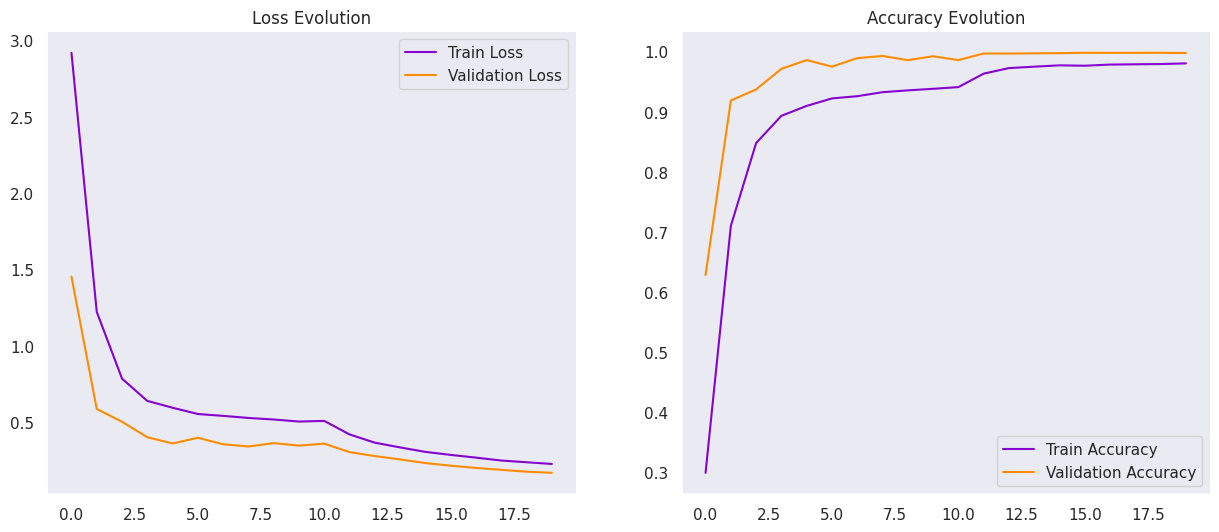

In [88]:
plt.figure(figsize=(15,6))

# Plotting the training and validation loss
plt.subplot(1, 2, 1)
plt.plot(model.history.history['loss'], label='Train Loss', color='#8502d1')
plt.plot(model.history.history['val_loss'], label='Validation Loss', color='darkorange')
plt.legend()
plt.title('Loss Evolution')

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(model.history.history['accuracy'], label='Train Accuracy', color='#8502d1')
plt.plot(model.history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
plt.legend()
plt.title('Accuracy Evolution')

plt.show()

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Total number of images in test set:12630, Array:[ 9 10  3 13 32  8  9 13  3  1]


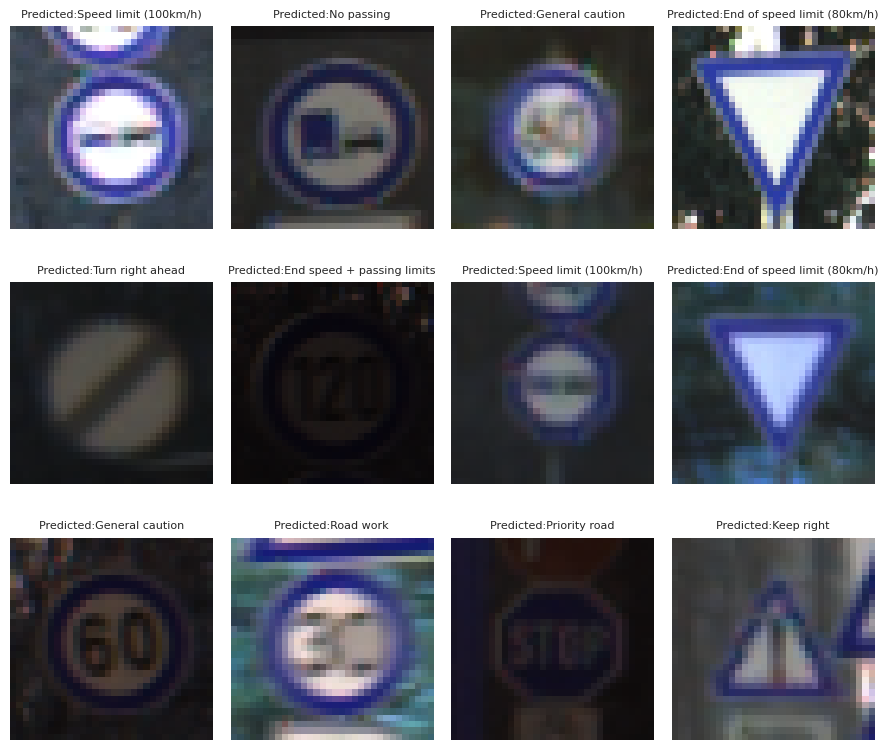

In [89]:
## Predicting with test set
y_pred=model.predict(x_test)

## Getting predicted classes
predicted_class=np.argmax(y_pred,axis=1)
print(f"Total number of images in test set:{len(predicted_class)}, Array:{predicted_class[:10]}")

## Visualizing few images
fig, axes = plt.subplots(3, 4, figsize=(9, 8))
axes=axes.flatten()

for ax in axes:
  ax.axis("off")

for i in range(12):
  axes[i].imshow(x_test[i])
  axes[i].set_title(f"Predicted:{labels[predicted_class[i]]}",fontsize=8)
  axes[i].axis('off') ## Hiding the x & y axis

plt.tight_layout()
plt.show()



#### Confusion Matrix on TensorFlow Trained Model

246/246 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


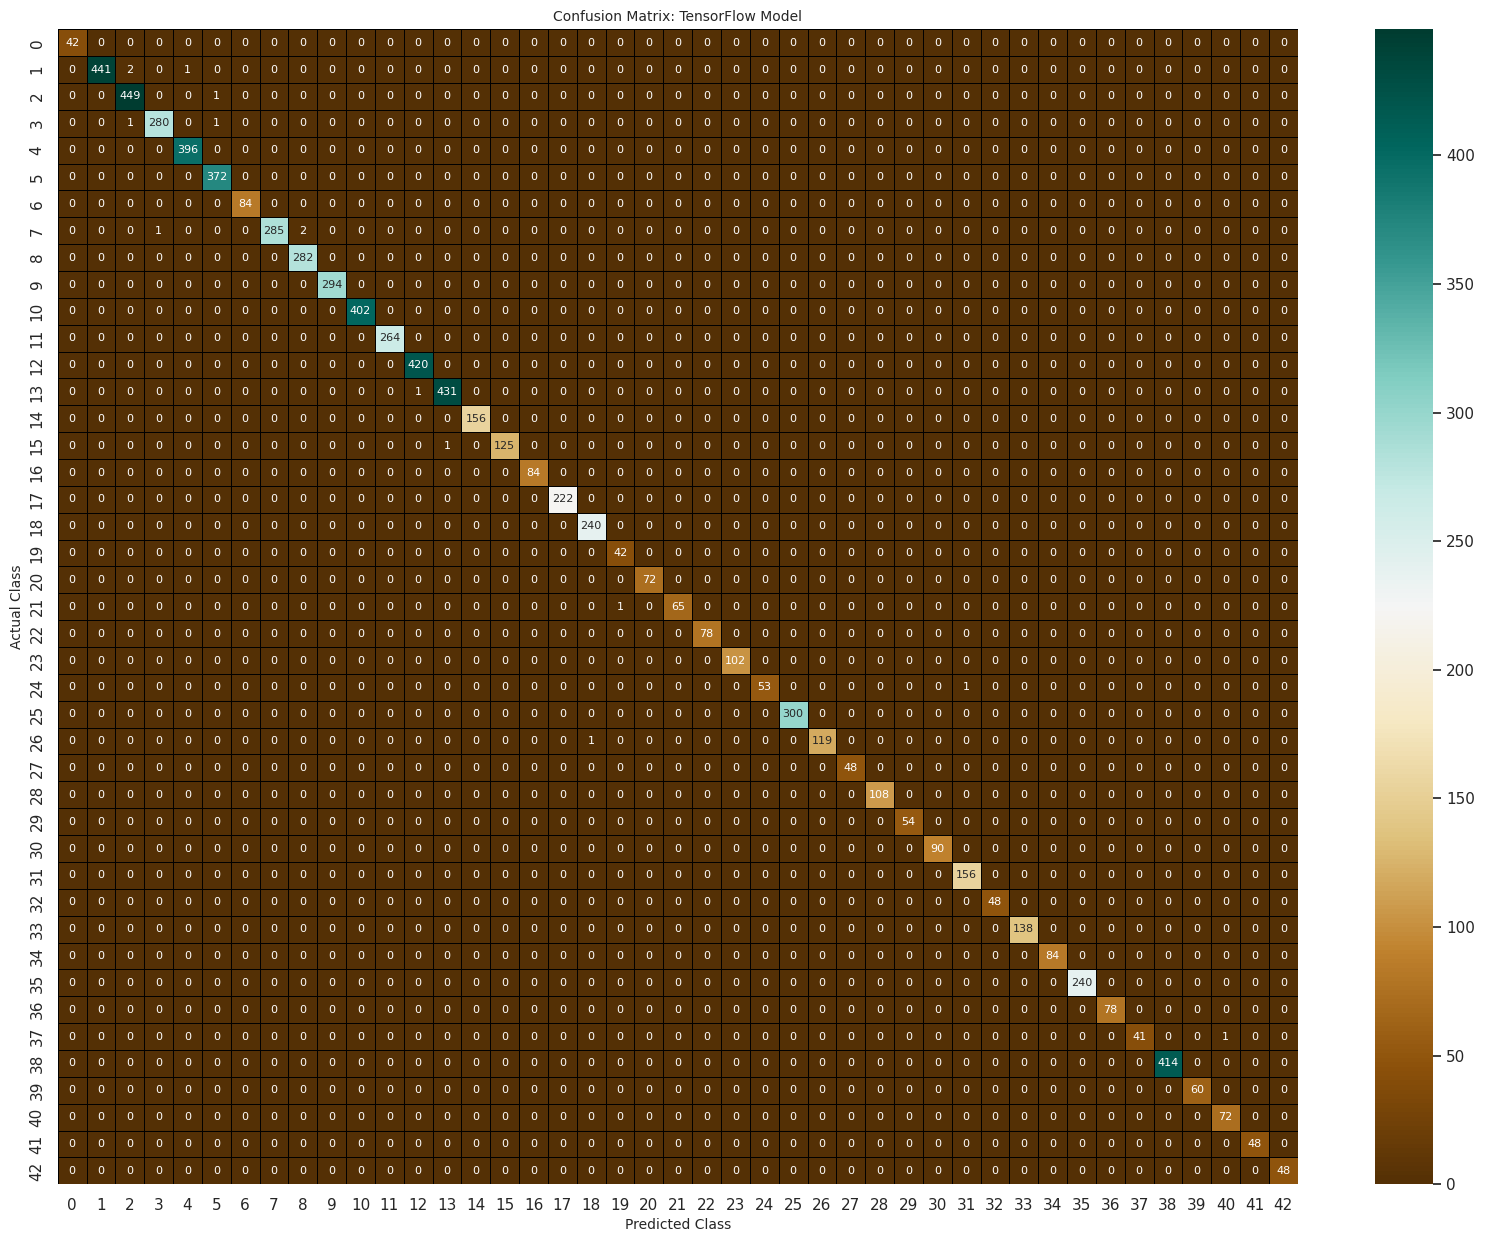

In [90]:
from sklearn.metrics import confusion_matrix

# model prediction on validation data
val_pred=model.predict(X_val)
val_pred_classes=np.argmax(val_pred,axis=1)

# Convert Y_val from one-hot encoded to single integer labels
y_val_labels = np.argmax(Y_val, axis=1)

cm=confusion_matrix(y_val_labels, val_pred_classes)

plt.figure(figsize=(20,15))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='BrBG', #sns.cubehelix_palette(as_cmap=True)
    linewidth=.5,
    xticklabels=np.unique(y_val_labels),
    yticklabels=np.unique(y_val_labels),
    linecolor='black',
    annot_kws={"size": 8}
)
plt.xlabel('Predicted Class',fontsize=10)
plt.ylabel('Actual Class',fontsize=10)
plt.title('Confusion Matrix: TensorFlow Model',fontsize=10)
plt.show()

### Transfer Learning: VGG16

In [ ]:
# Split the dataframe manually to prevent validation augmentation leakage
train_df_split, val_df_split = train_test_split(
    train_df, 
    test_size=0.20, 
    random_state=42, 
    stratify=train_df['labels'] # Ensures balanced classes in both sets
)

img_w, img_h = 170, 170
batch_s = 32

# Train datagen WITH augmentation and VGG16 preprocessing
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # <--- Use it for better model performance in place of rescale=1/255
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
)

# Val/Test datagen WITHOUT augmentation, only VGG16 preprocessing
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input # <--- Use it for better model performance in place of rescale=1/255
)

# Generating Images
train_set = train_datagen.flow_from_dataframe(
    dataframe=train_df_split,
    x_col='paths',
    y_col='labels',
    target_size=(img_w,img_h),
    batch_size=batch_s,
    class_mode='sparse',
    shuffle=True
)

# Notice: Used test_datagen here so validation data is NOT augmented
validation_set = test_datagen.flow_from_dataframe(
    dataframe=val_df_split,
    x_col='paths',
    y_col='labels',
    target_size=(img_w,img_h),
    batch_size=batch_s,
    class_mode='sparse',
    shuffle=False # Set to False for clean evaluation
)

test_set = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='paths',
    target_size=(img_w,img_h),
    batch_size=batch_s,
    class_mode=None,
    shuffle=False # CRITICAL: Set to False so predictions map to test_df correctly
)

print(f"Train Set: {train_set.samples}")
print(f"Validation Set: {validation_set.samples}")
print(f"Test Set: {test_set.samples}")
print(f"Total Classes: {train_set.class_indices}")

Found 31367 validated image filenames belonging to 43 classes.
Found 7842 validated image filenames belonging to 43 classes.
Found 12630 validated image filenames.
Train Set: 31367
Validation Set: 7842
Test Set: 12630
Total Classes: {'Ahead only': 0, 'Beware of ice/snow': 1, 'Bicycles crossing': 2, 'Bumpy road': 3, 'Children crossing': 4, 'Dangerous curve left': 5, 'Dangerous curve right': 6, 'Double curve': 7, 'End no passing veh > 3.5 tons': 8, 'End of no passing': 9, 'End of speed limit (80km/h)': 10, 'End speed + passing limits': 11, 'General caution': 12, 'Go straight or left': 13, 'Go straight or right': 14, 'Keep left': 15, 'Keep right': 16, 'No entry': 17, 'No passing': 18, 'No passing veh over 3.5 tons': 19, 'No vehicles': 20, 'Pedestrians': 21, 'Priority road': 22, 'Right-of-way at the next intersection': 23, 'Road narrows on the right': 24, 'Road work': 25, 'Roundabout mandatory': 26, 'Slippery road': 27, 'Speed limit (100km/h)': 28, 'Speed limit (120km/h)': 29, 'Speed limit

In [ ]:
callbacks_ = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1),
    ModelCheckpoint(
        filepath='best_vgg16_model.keras', # Or .h5 if using older Keras versions
        monitor='val_loss',
        save_best_only=True, 
        verbose=1
    )
    ]

In [104]:
base_model = VGG16(include_top=False, input_shape=(170,170,3), weights="imagenet")
base_model.trainable = False

# Unfreeze only last conv block of VGG16
for layer in base_model.layers[-4:]:
    layer.trainable = True

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

loss=tf.keras.losses.SparseCategoricalCrossentropy()

model.compile(
    optimizer=Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# fitting the model
history = model.fit(
    train_set,
    epochs=20,
    validation_data=validation_set,
    callbacks=callbacks_,
    verbose=1
)

/home/prashant/.conda/envs/deeplearning/lib/python3.13/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 157s 158ms/step - accuracy: 0.6326 - loss: 1.4048 - val_accuracy: 0.8673 - val_loss: 0.5956 - learning_rate: 1.0000e-04
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 142s 145ms/step - accuracy: 0.9247 - loss: 0.2593 - val_accuracy: 0.9513 - val_loss: 0.1565 - learning_rate: 1.0000e-04
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 145s 148ms/step - accuracy: 0.9592 - loss: 0.1373 - val_accuracy: 0.9686 - val_loss: 0.1000 - learning_rate: 1.0000e-04
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 140s 142ms/step - accuracy: 0.9731 - loss: 0.0921 - val_accuracy: 0.9797 - val_loss: 0.0673 - learning_rate: 1.0000e-04
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 131s 134ms/step - accuracy: 0.9801 - loss: 0.0674 - val_accuracy: 0.9748 - val_loss: 0.0845 - learning_rate: 1.0000e-04
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 131s 134ms/step - accuracy: 0.9843 - loss: 0.0557 - val_accuracy: 0.9819 - val_loss: 0.0598 - learning_rate: 1.0000e-04
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 

#### Saving the Model

In [105]:
model.save('traffic_sign_recognition_vgg16_model.keras')

/home/prashant/.conda/envs/deeplearning/lib/python3.13/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


395/395 ━━━━━━━━━━━━━━━━━━━━ 42s 106ms/step
Total number of images in test set:12630, Array:[18 19 33 42 11 29 18 42 33 31]


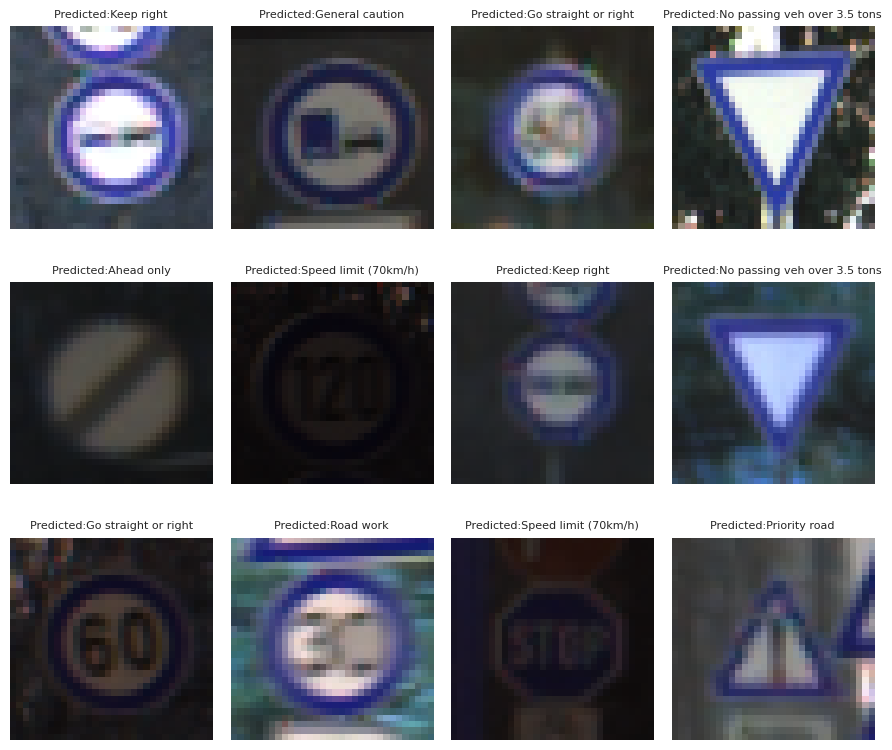

In [106]:
## Predicting with test set
y_pred=model.predict(test_set)

## Getting predicted classes
predicted_class=np.argmax(y_pred,axis=1)
print(f"Total number of images in test set:{len(predicted_class)}, Array:{predicted_class[:10]}")

## Visualizing few images
fig, axes = plt.subplots(3, 4, figsize=(9, 8))
axes=axes.flatten()

for ax in axes:
  ax.axis("off")

for i in range(12):
  axes[i].imshow(x_test[i])
  axes[i].set_title(f"Predicted:{labels[predicted_class[i]]}",fontsize=8)
  axes[i].axis('off') ## Hiding the x & y axis

plt.tight_layout()
plt.show()

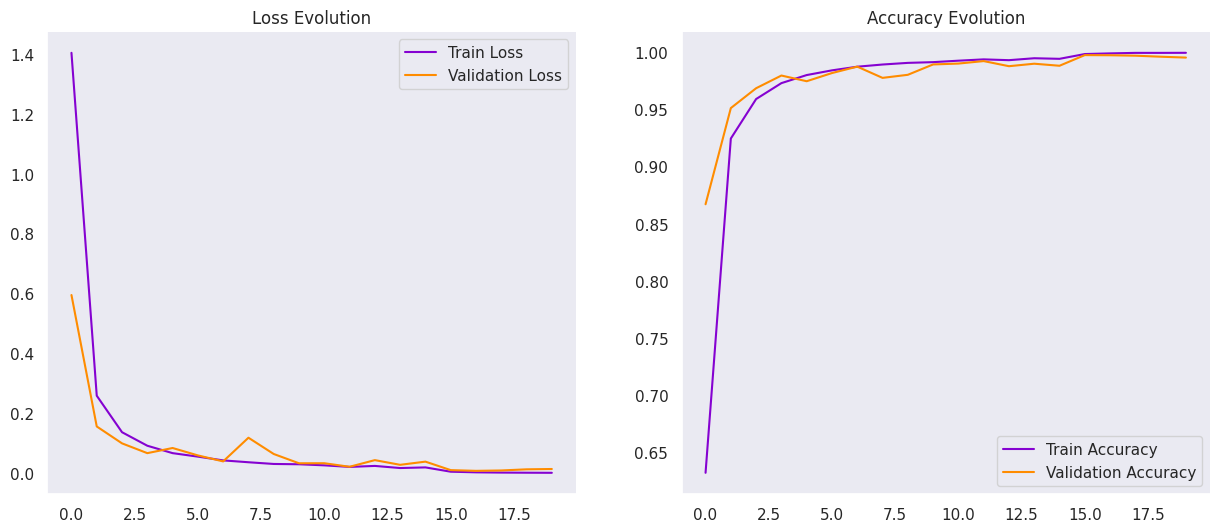

In [107]:
plt.figure(figsize=(15,6))

# Plotting the training and validation loss
plt.subplot(1, 2, 1)
plt.plot(model.history.history['loss'], label='Train Loss', color='#8502d1')
plt.plot(model.history.history['val_loss'], label='Validation Loss', color='darkorange')
plt.legend()
plt.title('Loss Evolution')

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(model.history.history['accuracy'], label='Train Accuracy', color='#8502d1')
plt.plot(model.history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
plt.legend()
plt.title('Accuracy Evolution')

plt.show()

This notebook demonstrates two approaches to traffic sign recognition using the GTSRB dataset: [Link](https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign)
accuracy:  - loss:  - val_accuracy:  - val_loss:  - learning_rate: 2.0000e-04
1. Custom CNN Model:
  - Training History (Epoch 19):
    * Train Loss: 0.2307
    * Train Accuracy: 0.9809
    * Validation Loss: 0.1728
    * Validation Accuracy: 0.9981


2. VGG16 Transfer Learning Model:
  - Training History (Epoch 19):
    * Train Loss: 0.0024
    * Train Accuracy: 0.9995
    * Validation Loss: 0.0095
    * Validation Accuracy: 0.9971

It appears that the custom CNN & VGG16 models achieved good performance on this dataset with both approach as implemented, with a much higher validation accuracy and lower validation loss.